# Topic Modelling Starter

This notebook sets up a reusable workflow for LDA and BERTopic on the news dataset.

In [5]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from gensim import corpora
from gensim.models import CoherenceModel

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


In [6]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\WEWL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\WEWL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\WEWL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
DATA_PATH = r"C:\Users\WEWL\OneDrive - Capco\Desktop\ADS Assessment\Data\NLP_data.csv"

TEXT_COLUMN = "content"
SAMPLE_SIZE = None

df = pd.read_csv(DATA_PATH)
print(df.shape)

df = df.dropna(subset=[TEXT_COLUMN]).copy()
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df = df.dropna(subset=["published_at"]).copy()
df = df[["article_id","source_name", "title", "category", "published_at", TEXT_COLUMN]].copy()

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

df.head()
print(df.shape)

(105375, 12)
(62932, 6)


In [8]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [token for token in tokens if len(token) > 2 and token not in stop_words]
    return tokens

df["tokens"] = df[TEXT_COLUMN].apply(clean_text)
df["clean_text"] = df["tokens"].apply(lambda tokens: " ".join(tokens))
df["published_date"] = df["published_at"].dt.date
df["published_year"] = df["published_at"].dt.year
df["published_month"] = df["published_at"].dt.to_period("M").astype(str)

sia = SentimentIntensityAnalyzer()
df["sentiment_score"] = df[TEXT_COLUMN].apply(lambda text: sia.polarity_scores(str(text))["compound"])
df["sentiment_label"] = pd.cut(
    df["sentiment_score"],
    bins=[-1.0, -0.05, 0.05, 1.0],
    labels=["Negative", "Neutral", "Positive"]
)

df[["title", "category", "published_at", "published_month", "sentiment_label", "clean_text"]].head()


,title,category,published_at,published_month,sentiment_label,clean_text
0,UN Chief Urges World To 'Stop The Madness' Of ...,Nepal,2023-10-30 10:12:35+00:00,2023-10,Negative,secretary general antonio guterres urged world...
1,RANDEBOOよりワンランク上の大人っぽさが漂うニットとベストが新登場。,Nepal,2023-10-06 04:40:02+00:00,2023-10,Neutral,randeboo web autumn winter nepal handmade ram ...
2,UN Chief Urges World to 'Stop the Madness' of ...,Nepal,2023-10-30 10:53:30+00:00,2023-10,Negative,kathmandu nepal secretary general antonio gute...
3,Sikkim warning: Hydroelectricity push must be ...,Nepal,2023-10-06 01:20:24+00:00,2023-10,Negative,least persons lost lives others including army...
4,"200 foreigners, dual nationals cut down in Ham...",Nepal,2023-10-27 01:08:34+00:00,2023-10,Negative,scores foreign citizens killed taken hostage l...


In [9]:

print(df.shape)

(62932, 13)


In [10]:
print(df.shape)
print(df["category"].fillna("Unknown").value_counts().head(10))
df[["published_at", "published_month", "sentiment_score", "sentiment_label"]].head()

date_min = df["published_at"].min()
date_max = df["published_at"].max()

print("Earliest date:", date_min.date())
print("Latest date:", date_max.date())
print("Date range:", date_max - date_min)

(62932, 13)
category
Finance     842
News        820
Jobs        795
Weather     776
Cars        771
Politics    764
Games       743
Love        728
Food        723
Music       719
Name: count, dtype: int64
Earliest date: 2023-10-01
Latest date: 2023-11-03
Date range: 32 days 19:24:00


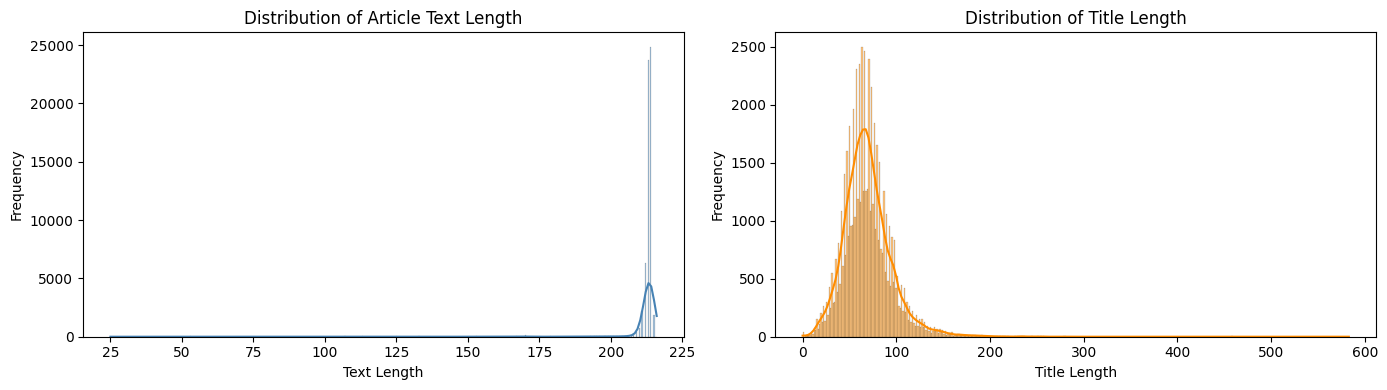

In [12]:
df["text_len"] = df[TEXT_COLUMN].fillna("").astype(str).apply(lambda x: len(x))
df["title_len"] = df["title"].fillna("").astype(str).apply(lambda x: len(x))


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))
sns.histplot(df["text_len"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Article Text Length")
axes[0].set_xlabel("Text Length")
axes[0].set_ylabel("Frequency")

sns.histplot(df["title_len"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Title Length")
axes[1].set_xlabel("Title Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


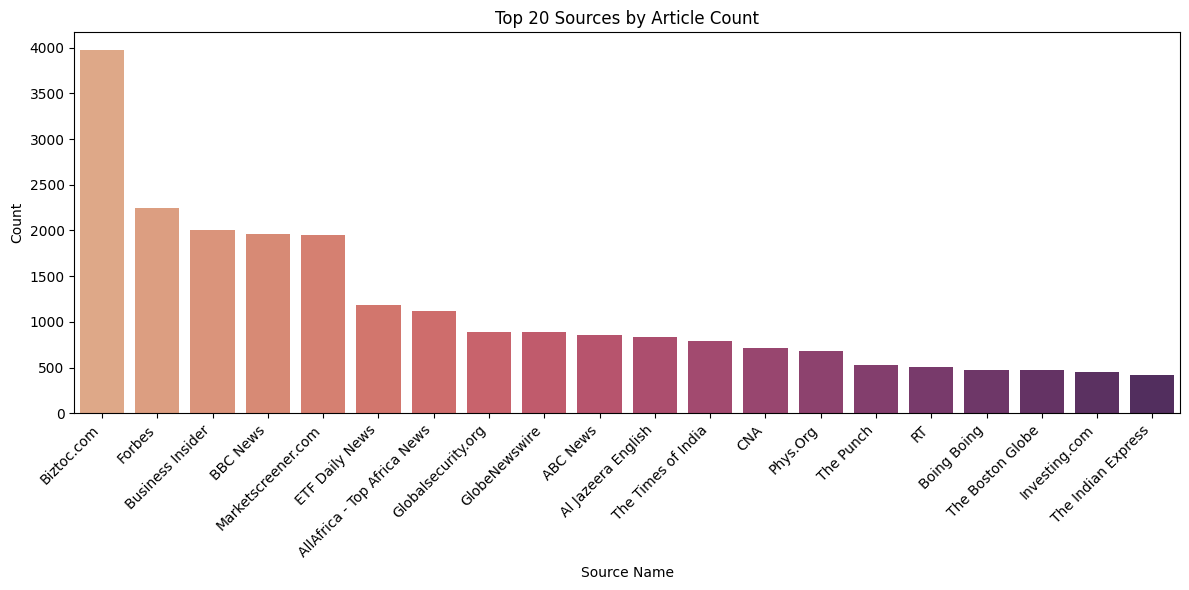

In [13]:
top_sources = (
    df["source_name"]
    .value_counts()
    .reset_index()
    .head(20)
)

top_sources.columns = ["source_name", "count"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sources, x="source_name", y="count", palette="flare")

plt.title("Top 20 Sources by Article Count")
plt.xlabel("Source Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


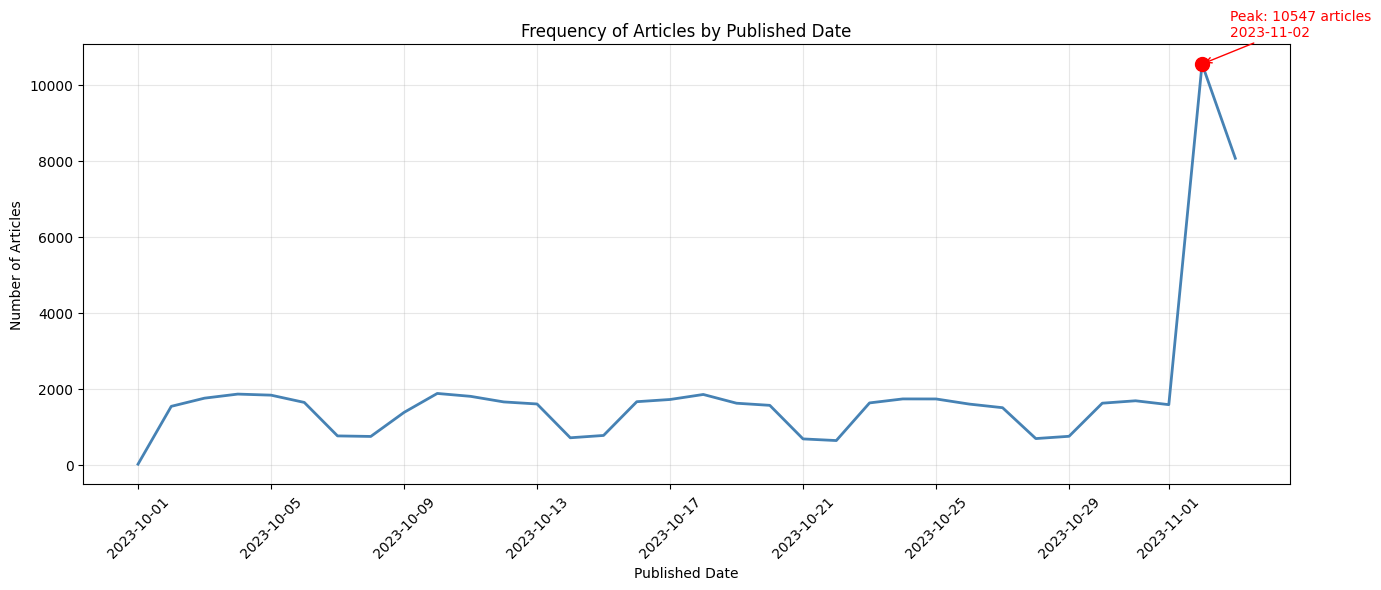

In [14]:
# Ensure dates are in datetime format
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)

articles_df = df.dropna(subset=["published_at"]).copy()
articles_df["published_date"] = articles_df["published_at"].dt.date

articles_by_date = (
    articles_df.groupby("published_date")
    .size()
    .reset_index(name="article_count")
)

articles_by_date["published_date"] = pd.to_datetime(articles_by_date["published_date"])

# Find peak
peak_row = articles_by_date.loc[articles_by_date["article_count"].idxmax()]

plt.figure(figsize=(14, 6))
plt.plot(
    articles_by_date["published_date"],
    articles_by_date["article_count"],
    color="steelblue",
    linewidth=2
)

# Highlight peak
plt.scatter(
    peak_row["published_date"],
    peak_row["article_count"],
    color="red",
    s=100,
    zorder=5
)

plt.annotate(
    f'Peak: {peak_row["article_count"]} articles\n{peak_row["published_date"].date()}',
    xy=(peak_row["published_date"], peak_row["article_count"]),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10,
    color="red"
)

plt.title("Frequency of Articles by Published Date")
plt.xlabel("Published Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

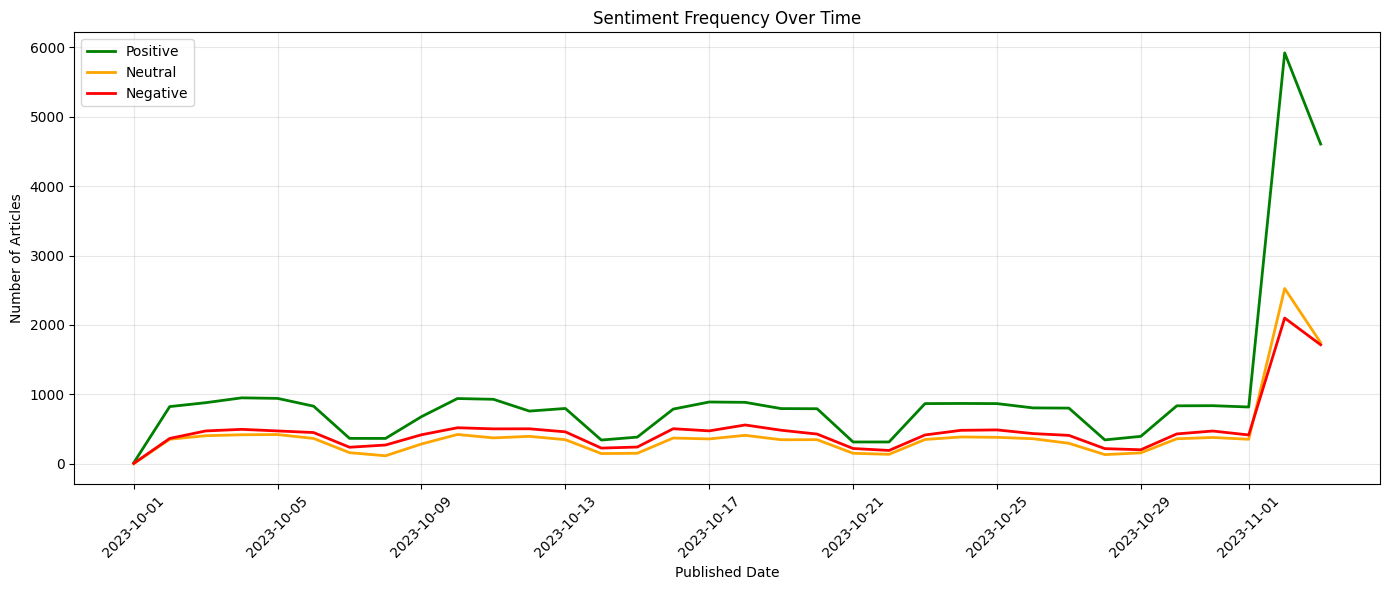

In [15]:
df["sentiment_label"] = pd.cut(
    df["sentiment_score"],
    bins=[-1.0, -0.05, 0.05, 1.0],
    labels=["Negative", "Neutral", "Positive"]
)

df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
sentiment_df = df.dropna(subset=["published_at"]).copy()
sentiment_df["published_date"] = sentiment_df["published_at"].dt.date

sentiment_counts = (
    sentiment_df.groupby(["published_date", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Positive", "Neutral", "Negative"]:
    if col not in sentiment_counts.columns:
        sentiment_counts[col] = 0

sentiment_counts = sentiment_counts.sort_index()
sentiment_counts.index = pd.to_datetime(sentiment_counts.index)

plt.figure(figsize=(14, 6))
plt.plot(sentiment_counts.index, sentiment_counts["Positive"], color="green", linewidth=2, label="Positive")
plt.plot(sentiment_counts.index, sentiment_counts["Neutral"], color="orange", linewidth=2, label="Neutral")
plt.plot(sentiment_counts.index, sentiment_counts["Negative"], color="red", linewidth=2, label="Negative")

plt.title("Sentiment Frequency Over Time")
plt.xlabel("Published Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.90,
    min_df=20,
    ngram_range=(1, 2)
)

doc_term_matrix = vectorizer.fit_transform(df["clean_text"])

In [17]:
for n in [5, 8, 10, 12]:
    lda_model = LatentDirichletAllocation(
        n_components=n,
        random_state=42,
        learning_method="batch"
    )
    lda_model.fit(doc_term_matrix)
    print(f"\nTop words for {n} topics:")
    feature_names = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


Top words for 5 topics:
Topic 1: getty, images, getty images, new, year, years, city, photo, team, university
Topic 2: said, israel, president, united, october, hamas, gaza, minister, people, state
Topic 3: new, like, time, world, year, season, video, games, series, best
Topic 4: world, news, cup, world cup, report, daily, england, live, free, africa
Topic 5: company, new, report, apple, market, announced, free, quarter, according, year

Top words for 8 topics:
Topic 1: getty, images, getty images, new, apple, health, school, artificial, intelligence, artificial intelligence
Topic 2: israel, said, president, hamas, gaza, united, october, minister, state, war
Topic 3: new, like, time, video, season, series, best, know, life, world
Topic 4: news, report, daily, research, free, morning, stories, reporting, sign, world
Topic 5: company, report, quarter, new, free, announced, google, apple, according, free report
Topic 6: new, globe, nov, global, newswire, globe newswire, climate, market, 

In [16]:
coherence_scores = {}
for n in [5, 8, 10, 12]:
    lda_model = LatentDirichletAllocation(
        n_components=n,
        random_state=42,
        learning_method="batch"
    )
    lda_model.fit(doc_term_matrix)
    
    topic_terms = []
    for topic in lda_model.components_:
        top_indices = topic.argsort()[:-11:-1]
        topic_terms.append([feature_names[i] for i in top_indices])
    
    coherence_model = CoherenceModel(
        topics=topic_terms,
        texts=df["tokens"],
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence_scores[n] = coherence_model.get_coherence()

print("Coherence scores for different k:")
for k, score in coherence_scores.items():
    print(f"k={k}: {score:.4f}")

Coherence scores for different k:
k=5: 0.6030
k=8: 0.4735
k=10: 0.4772
k=12: 0.4251


In [18]:
N_TOPICS = 5

vectorizer = CountVectorizer(max_df=0.95, min_df=10, stop_words="english")
doc_term_matrix = vectorizer.fit_transform(df["clean_text"])

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch"
)
lda_model.fit(doc_term_matrix)

# Print top words for each topic
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


Topic 1: new, time, year, world, season, like, day, years, series, games
Topic 2: getty, new, images, google, social, data, media, university, information, intelligence
Topic 3: new, world, apple, cup, year, news, com, latest, global, week
Topic 4: said, israel, president, united, hamas, october, gaza, people, minister, state
Topic 5: company, report, free, quarter, according, market, new, shares, global, nyse


In [19]:
# Assign each document to its dominant LDA topic
lda_topic_matrix = lda_model.transform(doc_term_matrix)
df["lda_topic"] = lda_topic_matrix.argmax(axis=1)


Topic 4
Number of articles: 15262
Average sentiment score: -0.13197272310313196
sentiment_label
Negative    7537
Positive    5124
Neutral     2601
Name: count, dtype: int64

Topic 5
Number of articles: 10599
Average sentiment score: 0.27214169261251064
sentiment_label
Positive    6753
Neutral     2394
Negative    1452
Name: count, dtype: int64


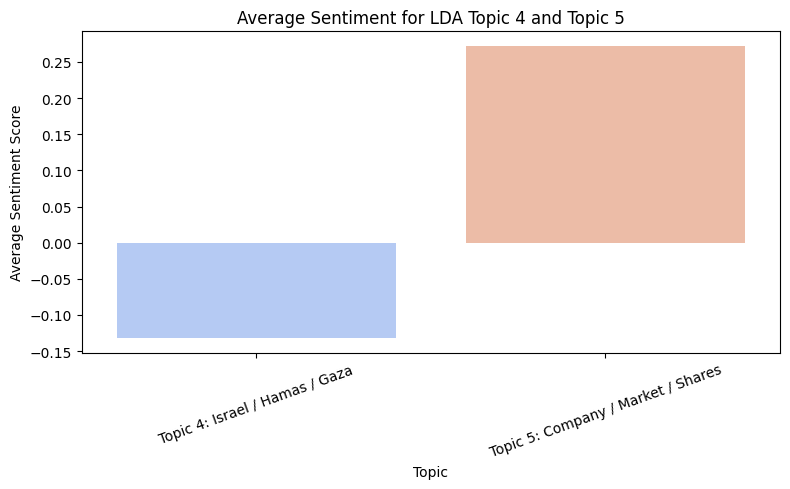

In [ ]:
selected_topics = [3, 4]

for topic_id in selected_topics:
    topic_df = df[df["lda_topic"] == topic_id].copy()

    print(f"\nTopic {topic_id + 1}")
    print("Number of articles:", topic_df.shape[0])
    print("Average sentiment score:", topic_df["sentiment_score"].mean())
    print(topic_df["sentiment_label"].value_counts(dropna=False))

topic_4_5_summary = (
    df[df["lda_topic"].isin([3, 4])]
    .groupby("lda_topic")["sentiment_score"]
    .agg(["mean", "count"])
    .reset_index()
)

topic_4_5_summary["Topic Name"] = [
    "Topic 4: Israel / Hamas / Gaza",
    "Topic 5: Company / Market / Shares"
]

plt.figure(figsize=(8, 5))
sns.barplot(data=topic_4_5_summary, x="Topic Name", y="mean", palette="coolwarm")
plt.title("Average Sentiment for LDA Topic 4 and Topic 5")
plt.xlabel("Topic")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=10,
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

In [ ]:
# ahahha this is the NMF version of the coherence loop
# same idea as LDA: try a few topic numbers and see which one gives the best coherence

dictionary = corpora.Dictionary(df["tokens"])
nmf_coherence_scores = {}

for k in [5, 8, 10, 12]:
    nmf_model = NMF(n_components=k, random_state=42)
    nmf_model.fit(tfidf_matrix)

    topic_terms = []
    for topic in nmf_model.components_:
        top_indices = topic.argsort()[:-11:-1]
        topic_terms.append([feature_names[i] for i in top_indices])

    coherence_model = CoherenceModel(
        topics=topic_terms,
        texts=df["tokens"],
        dictionary=dictionary,
        coherence="c_v"
    )

    nmf_coherence_scores[k] = coherence_model.get_coherence()

print("NMF Coherence scores for different k:")
for k, score in nmf_coherence_scores.items():
    print(f"k={k}: {score:.4f}")

best_nmf_k = max(nmf_coherence_scores, key=nmf_coherence_scores.get)
print(f"Best NMF k based on coherence: {best_nmf_k}")


,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",8
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [ ]:
# ahahha now refit NMF using the best number of topics from coherence
nmf_model = NMF(n_components=best_nmf_k, random_state=42)
nmf_model.fit(tfidf_matrix)

feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {", ".join(top_words)}")

nmf_topic_matrix = nmf_model.transform(tfidf_matrix)
df["nmf_topic"] = nmf_topic_matrix.argmax(axis=1)

df[["title", "category", "nmf_topic"]].head(10)


In [31]:
feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: new, year, york, apple, announced, getty, time, images, years, today
Topic 2: report, free, quarter, nyse, company, according, shares, recent, nasdaq, filing
Topic 3: news, stories, latest, live, cbs, breaking, analysis, features, coverage, beat
Topic 4: transmit, browsing, stored, collect, providers, personal, ads, data, information, device
Topic 5: page, adafruit, publishes, market, interviews, standards, wider, intended, writing, guide
Topic 6: israel, hamas, gaza, said, president, israeli, war, october, attack, united
Topic 7: world, cup, rugby, england, south, africa, final, table, cricket, india
Topic 8: commission, affiliate, links, advertising, earn, amazon, products, independently, program, purchase


In [43]:
# Get feature names from the NMF TF-IDF vectorizer
nmf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Helper to extract top words from an NMF topic
def get_nmf_top_words(model, feature_names, topic_idx, top_n=10):
    topic = model.components_[topic_idx]
    return [feature_names[i] for i in topic.argsort()[:-top_n - 1:-1]]



In [44]:
# Printed Topic 2 = index 1, Printed Topic 6 = index 5
nmf_topic_2_words = get_nmf_top_words(nmf_model, nmf_feature_names, topic_idx=1, top_n=10)
nmf_topic_6_words = get_nmf_top_words(nmf_model, nmf_feature_names, topic_idx=5, top_n=10)

print("NMF Topic 2 words:", nmf_topic_2_words)
print("NMF Topic 6 words:", nmf_topic_6_words)

# Filter documents that contain at least 2 of the model-found topic words
nmf_topic_2_df = df[
    df["clean_text"].apply(lambda x: sum(word in x.split() for word in nmf_topic_2_words) >= 2)
].copy()

nmf_topic_6_df = df[
    df["clean_text"].apply(lambda x: sum(word in x.split() for word in nmf_topic_6_words) >= 2)
].copy()




NMF Topic 2 words: ['report', 'free', 'quarter', 'nyse', 'company', 'according', 'shares', 'recent', 'nasdaq', 'filing']
NMF Topic 6 words: ['israel', 'hamas', 'gaza', 'said', 'president', 'israeli', 'war', 'october', 'attack', 'united']


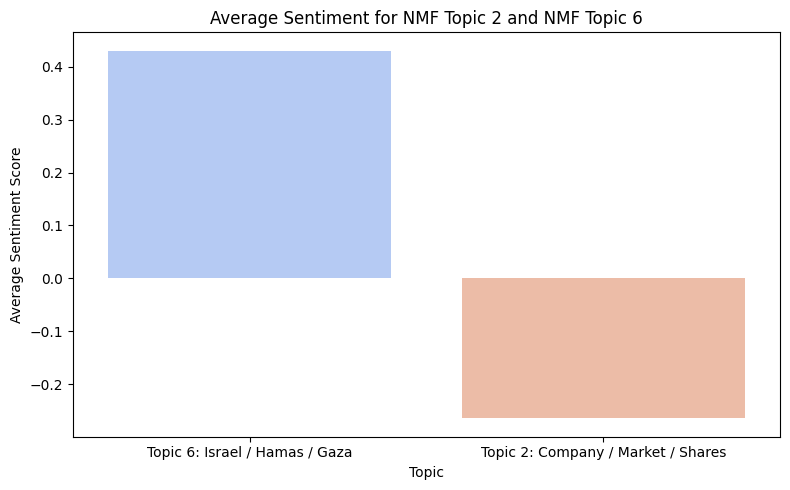

In [ ]:
# Build a separate NMF sentiment summary table
nmf_sentiment_summary = pd.DataFrame({
    "Topic": [
        "Topic 2: Company / Market / Shares",
        "Topic 6: Israel / Hamas / Gaza"
    ],
    "Average Sentiment": [
        nmf_topic_2_df["sentiment_score"].mean(),
        nmf_topic_6_df["sentiment_score"].mean()
    ],
    "Article Count": [
        nmf_topic_2_df.shape[0],
        nmf_topic_6_df.shape[0]
    ]
})

# Plot average sentiment
plt.figure(figsize=(8, 5))
sns.barplot(data=nmf_sentiment_summary, x="Topic", y="Average Sentiment", palette="coolwarm")
plt.title("Average Sentiment for NMF Topic 2 and NMF Topic 6")
plt.xlabel("Topic")
plt.ylabel("Average Sentiment Score")
plt.tight_layout()
plt.show()